# Logistic Regression Exercise

Now it's your turn to implement logistic regression on a new data set. For this purpose we use the Titanic Dataset. It includes personal information of all passengers on the Titanic as well as they survived the sinking of the Titanic or died.

Here’s the **Data Dictionary** of the dataset:

- PassengerID: type should be integers

- Survived: survived or not

- Pclass: class of Travel of every passenger

- Name: the name of the passenger

- Sex: gender

- Age: age of passengers

- SibSp: No. of siblings/spouse aboard

- Parch: No. of parent/child aboard

- Ticket: Ticket number

- Fare: what Prices they paid

- Cabin: cabin number

- Embarked: the port in which a passenger has embarked.

        - C: Cherbourg , S: Southampton , Q: Queenstown


You will find the data in the data folder (it's a zip folder, so you first have to unzip it).


## What you should do:

- conduct a brief EDA to become familiar with the data
- use Logistic Regression to predict if a passenger died or not

## How to do it:

Time is short, so aim for the simplest viable product first:
1. Load the data

2. Separate features and target 

3. Split the data in train and test

3. Get a quick overview of the train data

4. Agree on a classification metric for the task 

5. Create a simple heuristic/educated guess for the classification first. This is called a "baseline model". It is used to compare more complex models later (in this case: logistic regression). You as a data scientist want to prove how much your work/ML could improve the business metric, therefore you need a baseline model for comparison. In some cases you want to improve on an already existing model in your company which would be your baseline model then. In other cases, there are typical baseline models used in the specific field. For other tasks, you have to come up with a simple but meaningful idea, how to classify the data based on your business understanding (EDA). A baseline model should follow Occam’s Razor principle: "A simple model is the best model". 
    - Example of a baseline model: 
    If the task is to classify cats and dogs, a baseline model could be: We classify every animal as cat if its weight < 5 kg, otherwise the animal is classified as a dog. (The value of 5 kg is an educated guess, based on our business understanding/EDA.) 

6. use one or two already numerical features to create a simple first model
    -  did it even beat your base model?

7. Now you can go through the data science lifecycle again and again:
    - clean the data better

    - get more insights with EDA

    - add more features

    - do feature engineering 
    
    and check if your work improves your model further!

8. Stop whenever time is up or you cannot improve your model any further.

This repo a solution to this problem. If you want to compare your final result with the result of this repo solution, choose **25** as random seed and a test size of 30% for your train test split.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np

#from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from scipy.special import expit

#import sweetviz as sv

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['font.size'] = 14
plt.rcParams['figure.figsize'] = (11, 7)
sns.set_theme() 

df = pd.read_csv("data/titanic.csv")

y = df['Survived']
X=df.drop('Survived', axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3
                                                    )

Shape: 623 rows x 11 columns

<class 'pandas.core.frame.DataFrame'>
Index: 623 entries, 144 to 378
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  623 non-null    int64  
 1   Pclass       623 non-null    int64  
 2   Name         623 non-null    object 
 3   Sex          623 non-null    object 
 4   Age          498 non-null    float64
 5   SibSp        623 non-null    int64  
 6   Parch        623 non-null    int64  
 7   Ticket       623 non-null    object 
 8   Fare         623 non-null    float64
 9   Cabin        146 non-null    object 
 10  Embarked     622 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 58.4+ KB
None


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
144,145,2,"Andrew, Mr. Edgardo Samuel",male,18.0,0,0,231945,11.5000,NaN,S
424,425,3,"Rosblom, Mr. Viktor Richard",male,18.0,1,1,370129,20.2125,NaN,S
723,724,2,"Hodges, Mr. Henry Price",male,50.0,0,0,250643,13.0000,NaN,S
264,265,3,"Henry, Miss. Delia",female,NaN,0,0,382649,7.7500,NaN,Q
103,104,3,"Johansson, Mr. Gustaf Joel",male,33.0,0,0,7540,8.6542,NaN,S


Missings:            Total    Percent
Cabin       477  76.565008
Age         125  20.064205
Embarked      1   0.160514

=== NUMERICAL FEATURES ===
       PassengerId      Pclass         Age       SibSp       Parch        Fare
count   623.000000  623.000000  498.000000  623.000000  623.000000  623.000000
mean    440.622793    2.308186   29.893072    0.500803    0.391653   31.741987
std     254.734205    0.841859   14.817963    1.074215    0.814298   47.734484
min       2.000000    1.000000    0.420000    0.000000    0.000000    0.000000
25%     230.000000    2.000000   20.000000    0.000000    0.000000    7.895800
50%     442.000000    3.000000   28.000000    0.000000    0.000000   14.454200
75%     657.000000    3.000000   39.000000    1.000000    0.000000   31.331250
max     891.000000    3.000000   80.000000    8.000000    6.000000  512.329200

=== CATEGORICAL FEATURES ===

Name:
Name
Andrew, Mr. Edgardo Samuel             1
Berglund, Mr. Karl Ivar Sven           1
Sandstrom, Miss. M

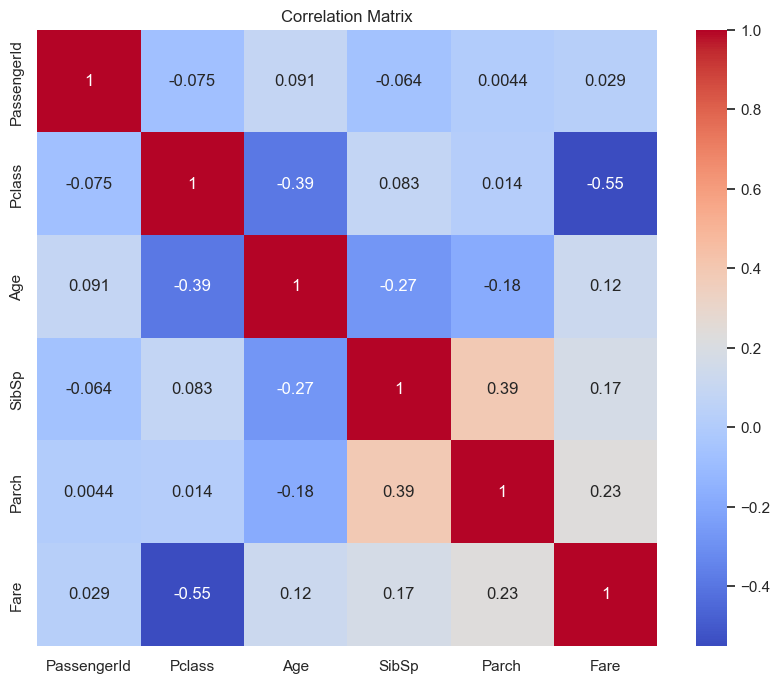

In [3]:
# EDA of training data
print(f"Shape: {X_train.shape[0]} rows x {X_train.shape[1]} columns\n")
print(X_train.info())
display(X_train.head())
missing = X_train.isnull().sum()
missing_pct = 100 * X_train.isnull().sum() / len(X_train)
missing_table = pd.concat([missing, missing_pct], axis=1, keys=['Total', 'Percent'])
print(f"Missings:  {missing_table[missing_table['Total'] > 0].sort_values('Total', ascending=False)}")

# 3. Numerische Features
print("\n=== NUMERICAL FEATURES ===")
print(X_train.describe())

# 4. Kategorische Features
print("\n=== CATEGORICAL FEATURES ===")
cat_cols = X_train.select_dtypes(include=['object']).columns
for col in cat_cols:
    print(f"\n{col}:")
    print(X_train[col].value_counts())

# 5. Korrelationen
print("\n=== CORRELATIONS ===")
print(X_train.select_dtypes(include=[np.number]).corr())

# Optional: Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(X_train.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [ ]:
# === SCHRITT 5: BASELINE MODEL ===
# Einfache Heuristik: "Frauen überleben, Männer nicht"
# (Historisch bekannt: "Women and children first")

baseline_pred = (X_test['Sex'] == 'female').astype(int)
print("Baseline Accuracy (Sex=female → survived):", accuracy_score(y_test, baseline_pred))

In [ ]:
# === SCHRITT 6: ERSTES EINFACHES MODELL ===
# Nur numerische Features ohne Missings verwenden

numeric_features = ['Pclass', 'SibSp', 'Parch', 'Fare']

X_train_simple = X_train[numeric_features].copy()
X_test_simple = X_test[numeric_features].copy()

# Fare hat wenige Missings - mit Median füllen
X_train_simple['Fare'].fillna(X_train_simple['Fare'].median(), inplace=True)
X_test_simple['Fare'].fillna(X_train_simple['Fare'].median(), inplace=True)

# Modell trainieren
lr = LogisticRegression()
lr.fit(X_train_simple, y_train)
y_pred = lr.predict(X_test_simple)

print("Simple Model Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

In [ ]:
# === SCHRITT 7: MODELL VERBESSERN ===
# Sex encodieren und Age hinzufügen

X_train_v2 = X_train[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']].copy()
X_test_v2 = X_test[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']].copy()

# Sex encodieren (female=1, male=0)
X_train_v2['Sex'] = (X_train_v2['Sex'] == 'female').astype(int)
X_test_v2['Sex'] = (X_test_v2['Sex'] == 'female').astype(int)

# Missings füllen (mit Median aus Train!)
X_train_v2['Age'].fillna(X_train_v2['Age'].median(), inplace=True)
X_test_v2['Age'].fillna(X_train_v2['Age'].median(), inplace=True)
X_train_v2['Fare'].fillna(X_train_v2['Fare'].median(), inplace=True)
X_test_v2['Fare'].fillna(X_train_v2['Fare'].median(), inplace=True)

# Modell trainieren
lr2 = LogisticRegression(max_iter=1000)
lr2.fit(X_train_v2, y_train)
y_pred2 = lr2.predict(X_test_v2)

print("Improved Model Accuracy:", accuracy_score(y_test, y_pred2))
print(classification_report(y_test, y_pred2))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred2))